<a href="https://www.kaggle.com/code/lalit7881/early-wakeup-health-lifestyle-eda-100?scriptVersionId=327535941" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/early-wakeup-health-and-lifestyle-dataset/early_wakeup_health_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/early-wakeup-health-and-lifestyle-dataset/early_wakeup_health_dataset.csv")

In [3]:
df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


In [4]:
df.tail()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
9995,P09996,66,Male,170.2,86.4,29.84,Nigeria,Teacher,Single,07:11,...,Medium,High,High,Medium,Low,67.8,Good,53.8,Good,No
9996,P09997,70,Male,182.3,86.9,26.14,Canada,Athlete,Single,09:33,...,Medium,High,Medium,Medium,Low,84.8,Excellent,78.5,Excellent,No
9997,P09998,29,Male,170.4,81.2,27.96,Italy,Lawyer,Married,07:58,...,Medium,Low,Medium,Low,Medium,54.2,Average,59.2,Average,No
9998,P09999,22,Male,186.5,78.3,22.52,India,Chef,Single,06:39,...,Low,Medium,Medium,Low,Medium,78.9,Good,84.2,Good,No
9999,P10000,58,Male,177.8,63.9,20.22,Brazil,Freelancer,Single,05:06,...,Low,Low,Low,Low,Low,88.7,Excellent,90.4,Excellent,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

In [6]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Sleep_Duration_Hours,Sleep_Quality_Score,Number_of_Night_Awakenings,Weekend_Sleep_Difference_Hours,Nap_Frequency_Per_Week,Screen_Time_Before_Bed_Hours,...,Fatigue_Level_Score,Immune_Health_Score,Mood_Score,Anxiety_Score,Depression_Risk_Score,Productivity_Score,Focus_Concentration_Score,Life_Satisfaction_Score,Health_Score,Healthy_Aging_Score
count,10000.0000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000
mean,44.6667,168.649160,73.10734,25.626963,7.229332,6.020190,0.839100,1.027020,2.120800,1.144012,...,3.124640,6.56333,6.779650,5.133470,2.184520,7.06533,6.85799,7.416720,74.201360,74.812320
std,17.5172,9.876706,16.29195,4.870317,1.118486,1.585689,0.936215,0.787941,1.905196,1.044281,...,1.705843,1.06034,1.255232,1.496242,1.286404,1.14750,0.95254,1.147736,12.266227,14.627688
min,18.0000,145.000000,33.60000,16.000000,4.000000,1.000000,0.000000,-1.000000,0.000000,0.000000,...,1.000000,2.60000,2.000000,1.000000,1.000000,2.80000,3.50000,2.900000,27.300000,12.400000
25%,29.7500,161.400000,61.30000,22.170000,6.470000,4.900000,0.000000,0.497500,0.750000,0.330000,...,1.700000,5.90000,5.900000,4.100000,1.000000,6.30000,6.20000,6.600000,66.000000,65.300000
50%,43.0000,168.200000,72.00000,25.580000,7.230000,6.000000,1.000000,1.030000,2.000000,0.810000,...,2.900000,6.60000,6.800000,5.100000,1.800000,7.00000,6.90000,7.400000,74.600000,75.700000
75%,58.0000,175.500000,83.50000,28.862500,7.980000,7.100000,1.000000,1.560000,3.000000,1.650000,...,4.300000,7.30000,7.700000,6.200000,2.900000,7.90000,7.50000,8.200000,82.800000,85.700000
max,80.0000,205.500000,166.60000,44.560000,10.000000,9.800000,6.000000,3.810000,7.000000,4.000000,...,10.000000,10.00000,10.000000,10.000000,8.800000,10.00000,10.00000,10.000000,100.000000,100.000000


In [7]:
df.isnull()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Person_ID              0
Age                    0
Gender                 0
Height_cm              0
Weight_kg              0
                      ..
Health_Score           0
Fitness_Level          0
Healthy_Aging_Score    0
Wellness_Category      0
Early_Waker            0
Length: 64, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Person_ID               object
Age                      int64
Gender                  object
Height_cm              float64
Weight_kg              float64
                        ...   
Health_Score           float64
Fitness_Level           object
Healthy_Aging_Score    float64
Wellness_Category       object
Early_Waker             object
Length: 64, dtype: object

In [11]:
df.shape

(10000, 64)

In [12]:
df.columns

Index(['Person_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI',
       'Country', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Sleep_Time',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score',
       'Number_of_Night_Awakenings', 'Weekend_Sleep_Difference_Hours',
       'Nap_Frequency_Per_Week', 'Screen_Time_Before_Bed_Hours',
       'Exercise_Frequency_Per_Week', 'Exercise_Duration_Minutes',
       'Exercise_Type', 'Daily_Steps', 'Morning_Workout', 'Workout_Intensity',
       'Gym_Member', 'Daily_Calorie_Intake', 'Water_Intake_Liters',
       'Fruit_Intake_Per_Day', 'Vegetable_Intake_Per_Day',
       'Protein_Intake_Grams', 'Sugary_Drinks_Per_Week',
       'Fast_Food_Meals_Per_Week', 'Breakfast_Regularity_Score',
       'Smoking_Status', 'Alcohol_Consumption', 'Stress_Level',
       'Working_Hours_Per_Day', 'Sitting_Hours_Per_Day', 'Outdoor_Time_Hours',
       'Social_Interaction_Score', 'Meditation_Practice', 'Resting_Heart_Rate',
       'Systolic_BP', 'Diastolic_BP', 'Cho

In [13]:
df.dtypes

Person_ID               object
Age                      int64
Gender                  object
Height_cm              float64
Weight_kg              float64
                        ...   
Health_Score           float64
Fitness_Level           object
Healthy_Aging_Score    float64
Wellness_Category       object
Early_Waker             object
Length: 64, dtype: object

In [14]:
df.nunique()

Person_ID              10000
Age                       63
Gender                     3
Height_cm                516
Weight_kg                847
                       ...  
Health_Score             617
Fitness_Level              4
Healthy_Aging_Score      691
Wellness_Category          4
Early_Waker                2
Length: 64, dtype: int64

## EDA

Shape: (10000, 64)

Missing Values:
Person_ID              0
Age                    0
Gender                 0
Height_cm              0
Weight_kg              0
                      ..
Health_Score           0
Fitness_Level          0
Healthy_Aging_Score    0
Wellness_Category      0
Early_Waker            0
Length: 64, dtype: int64


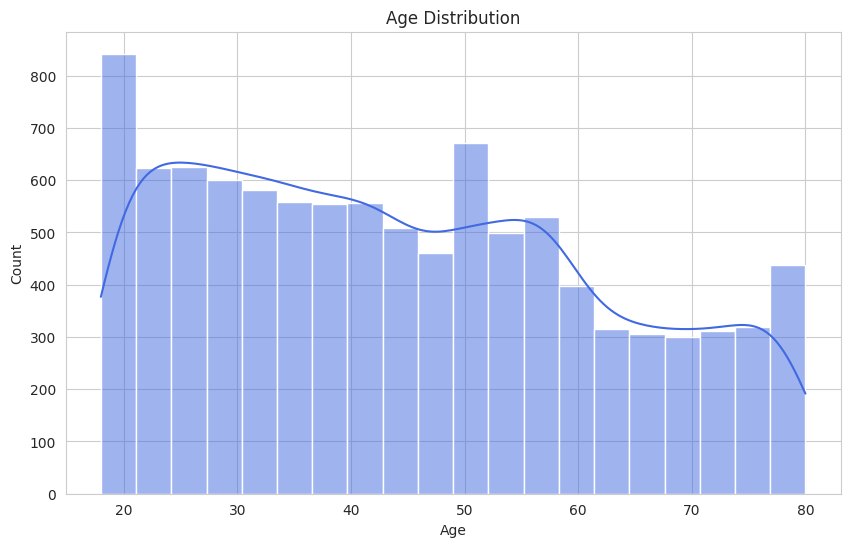

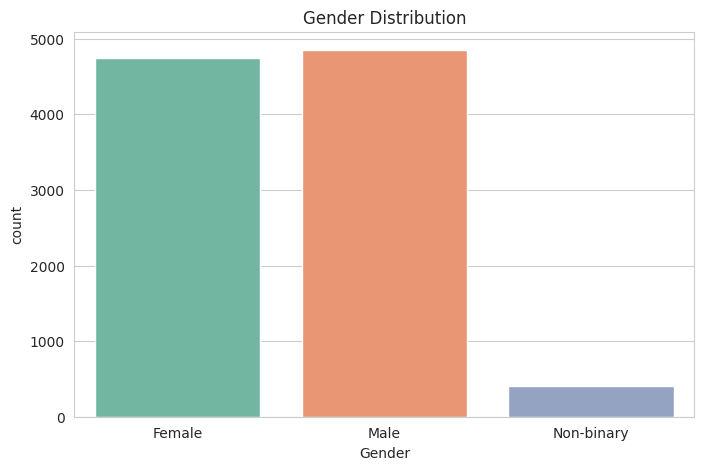

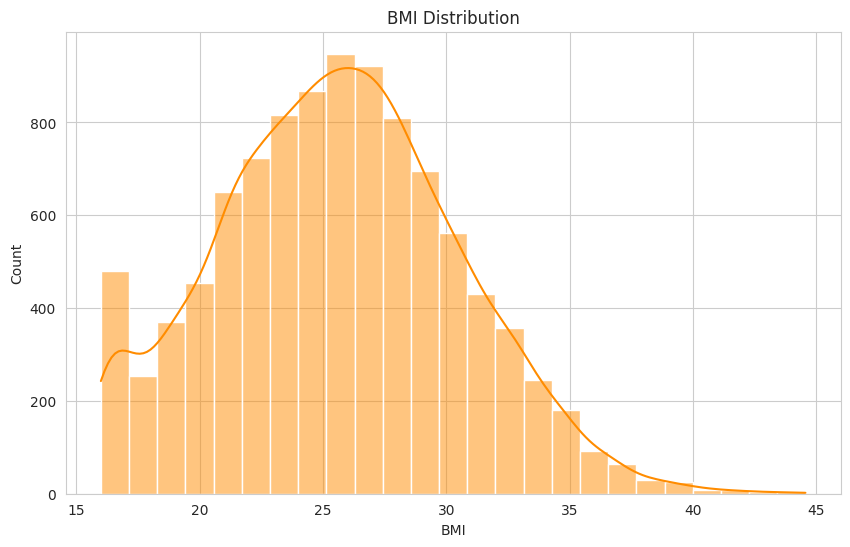

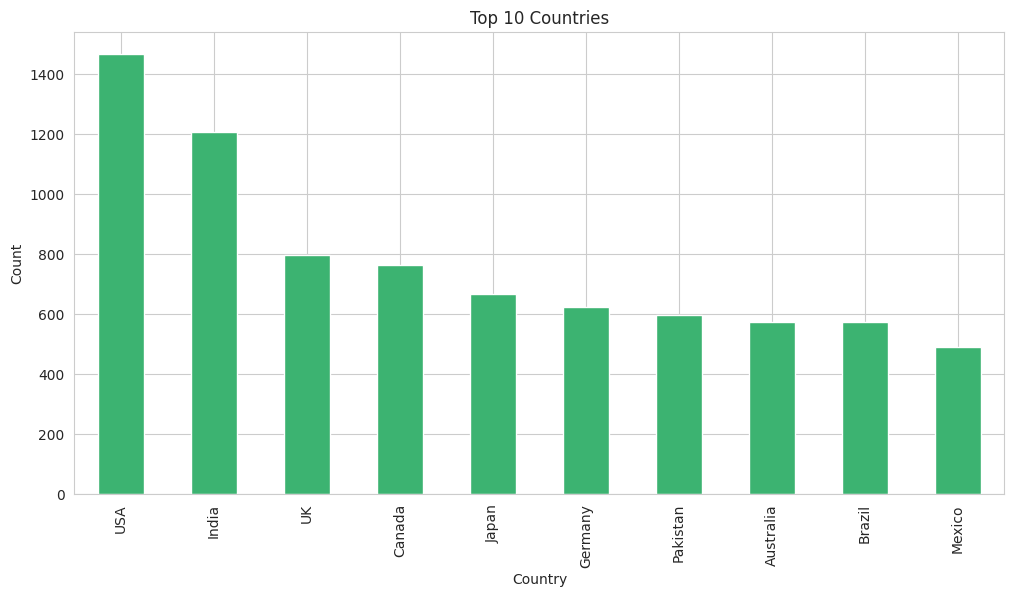

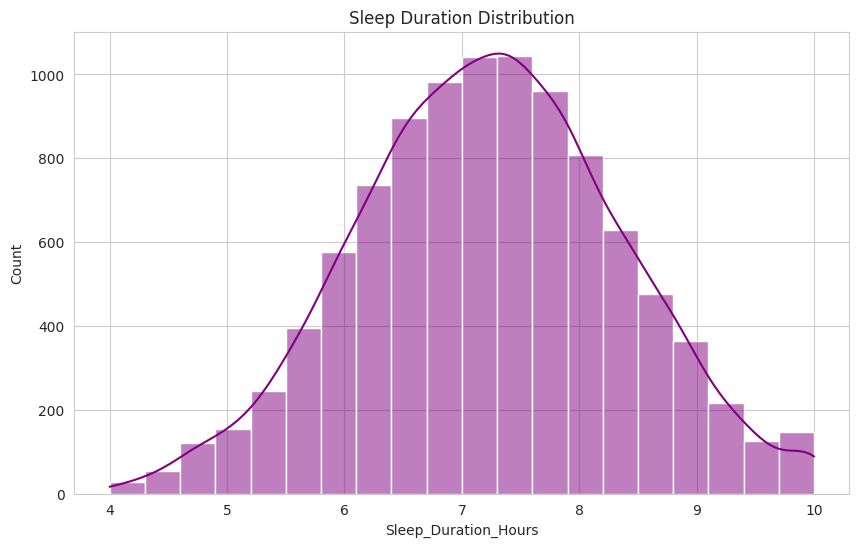

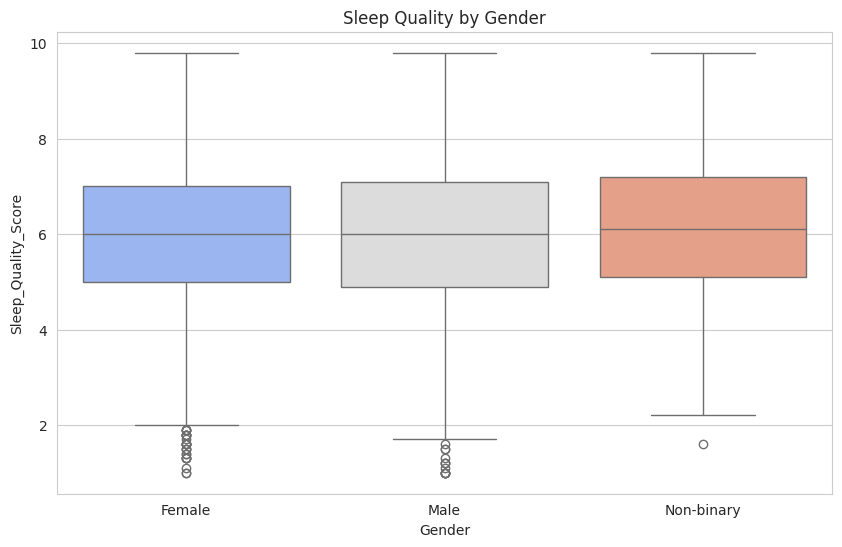

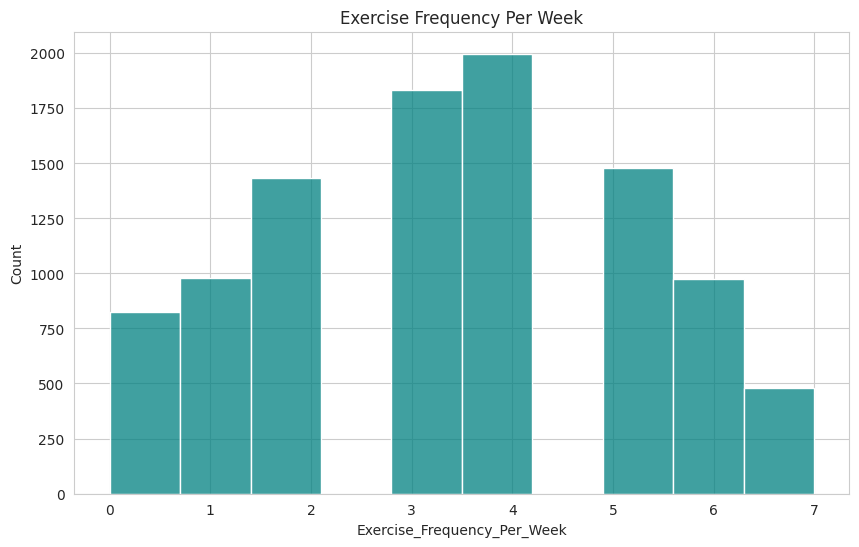

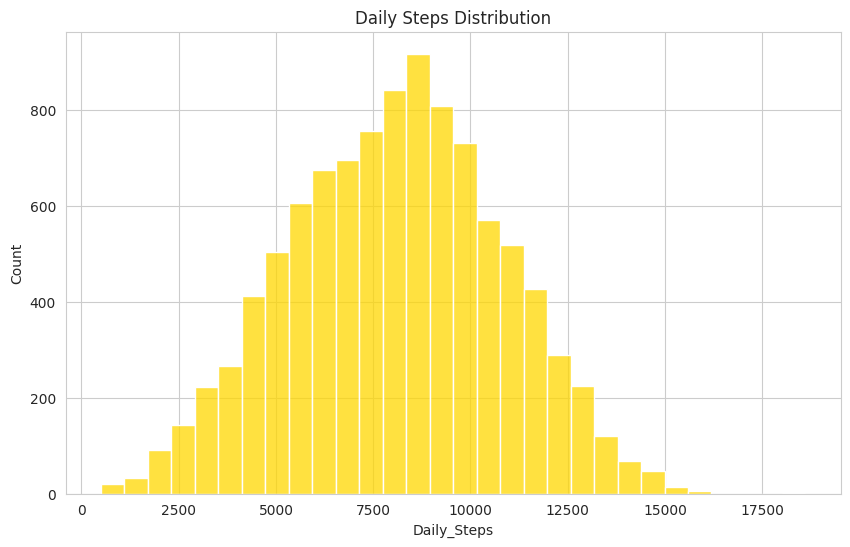

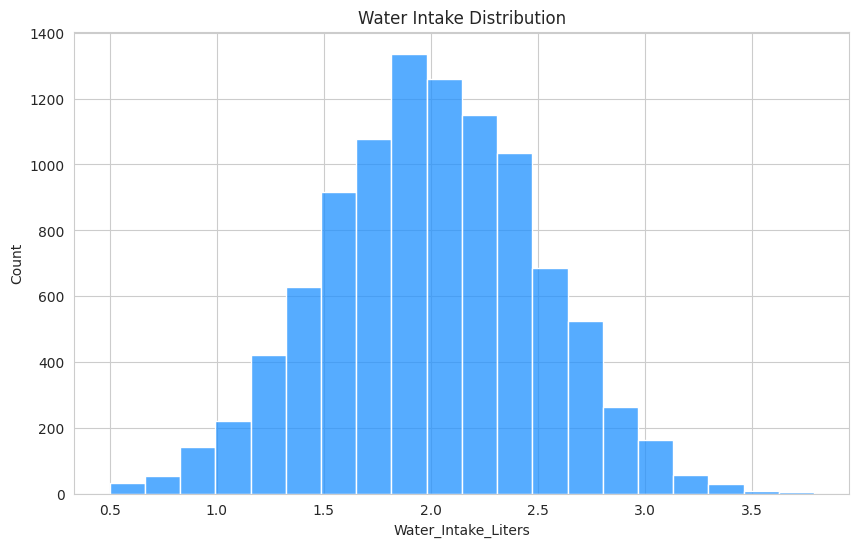

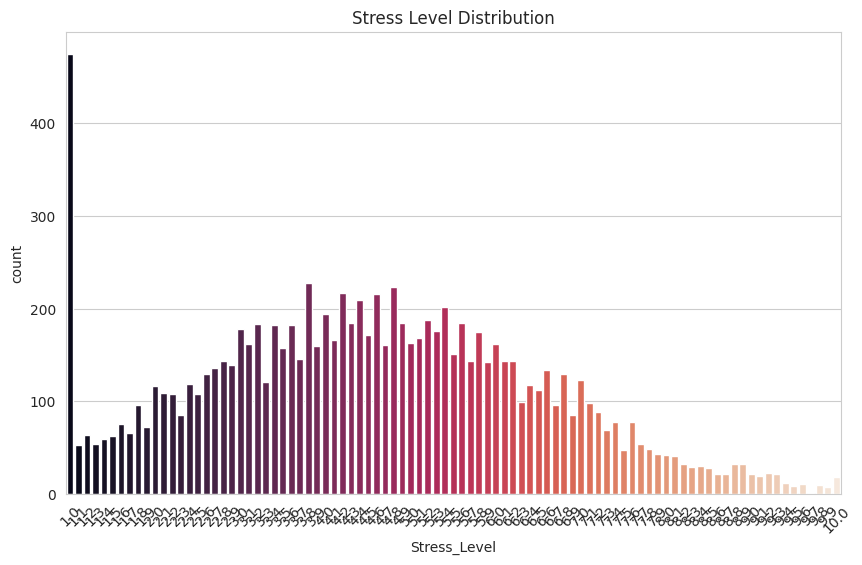

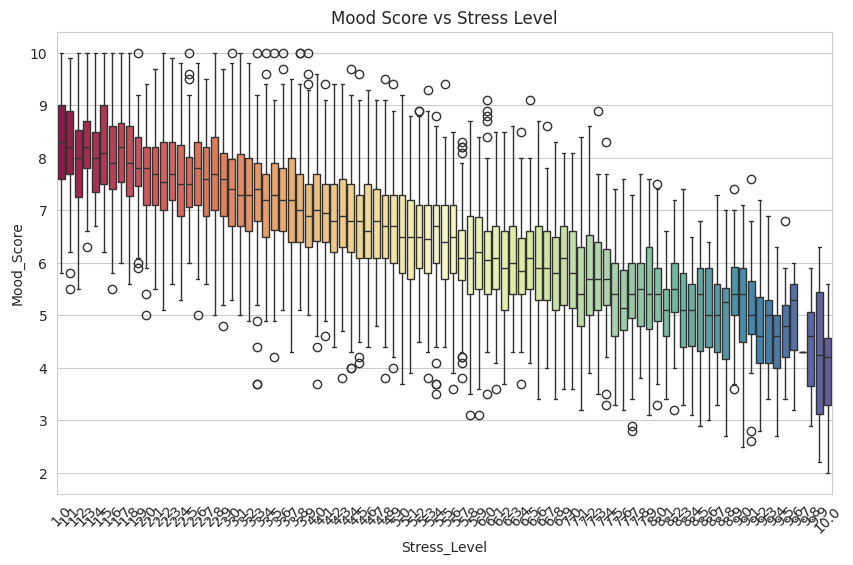

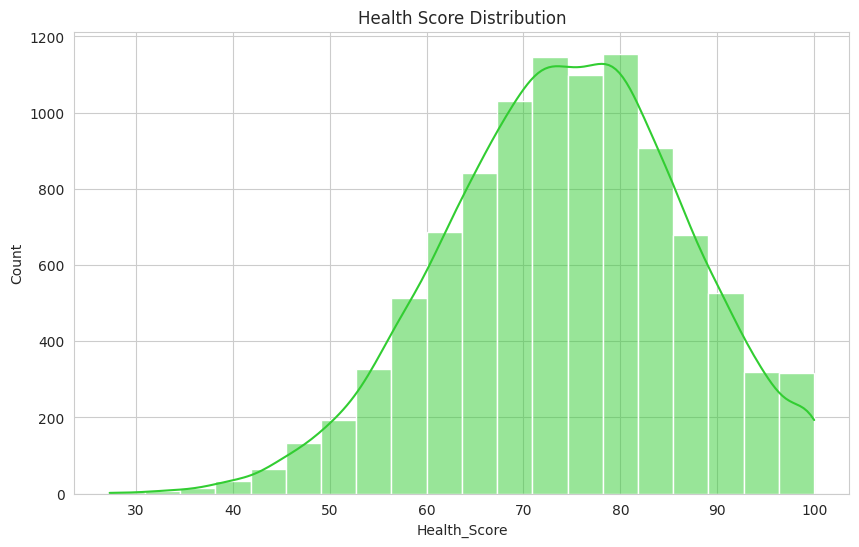

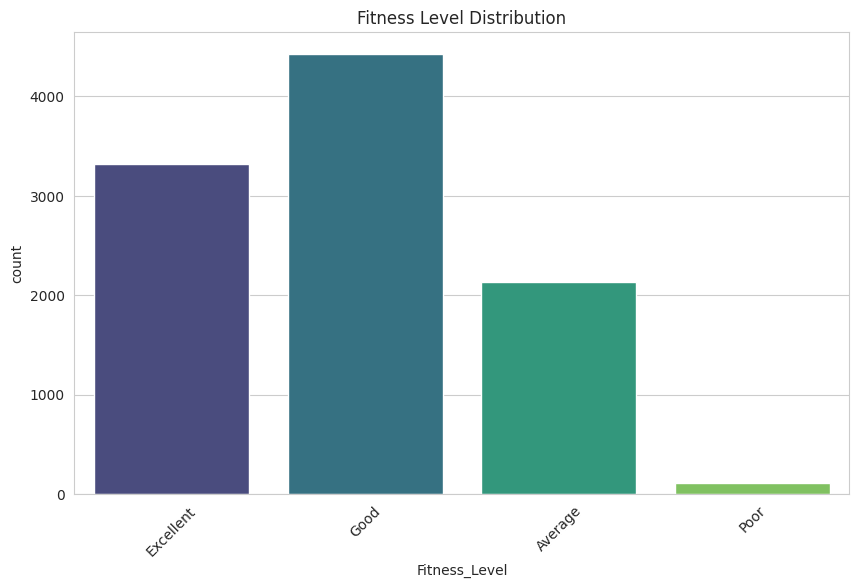

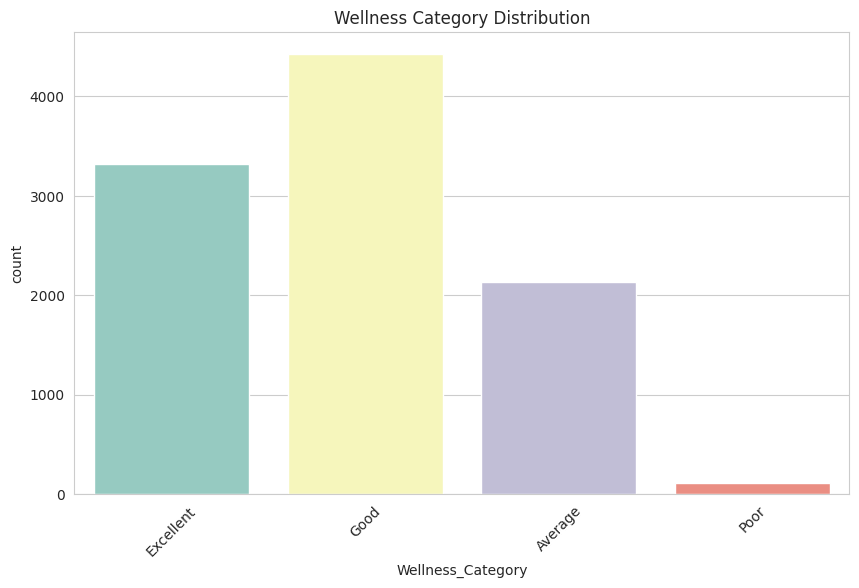

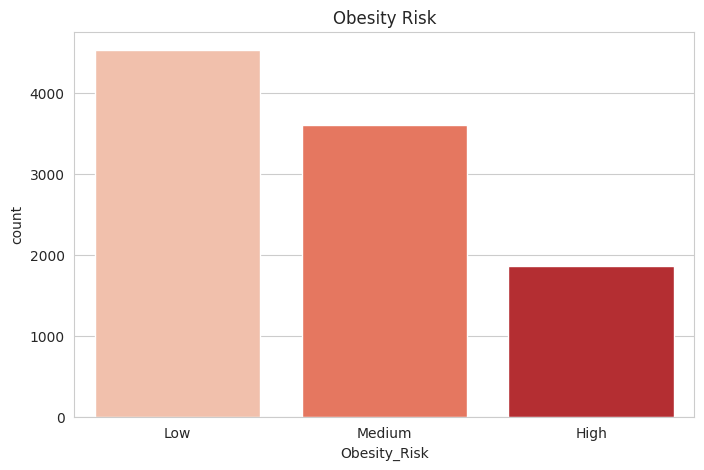

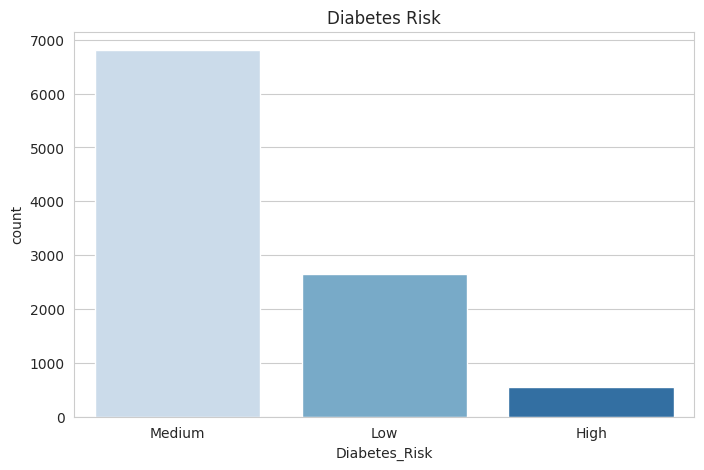

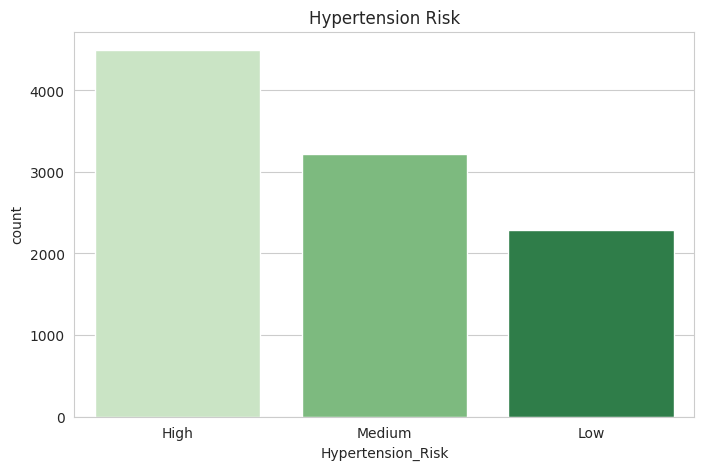

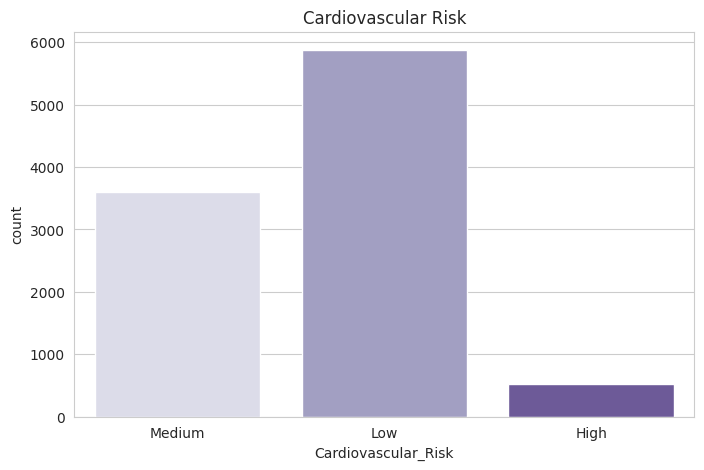

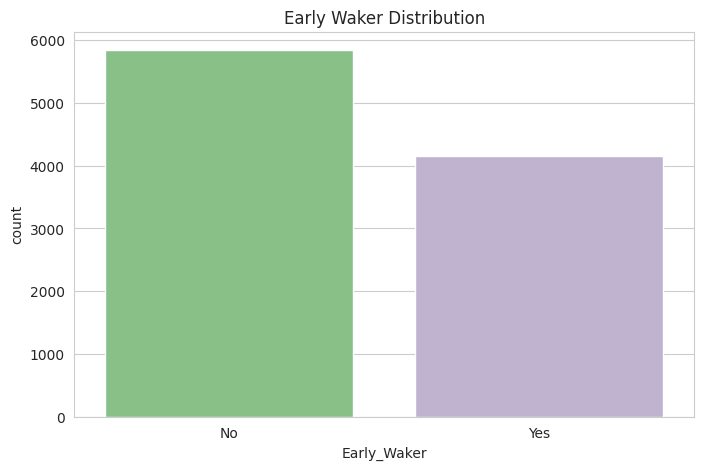

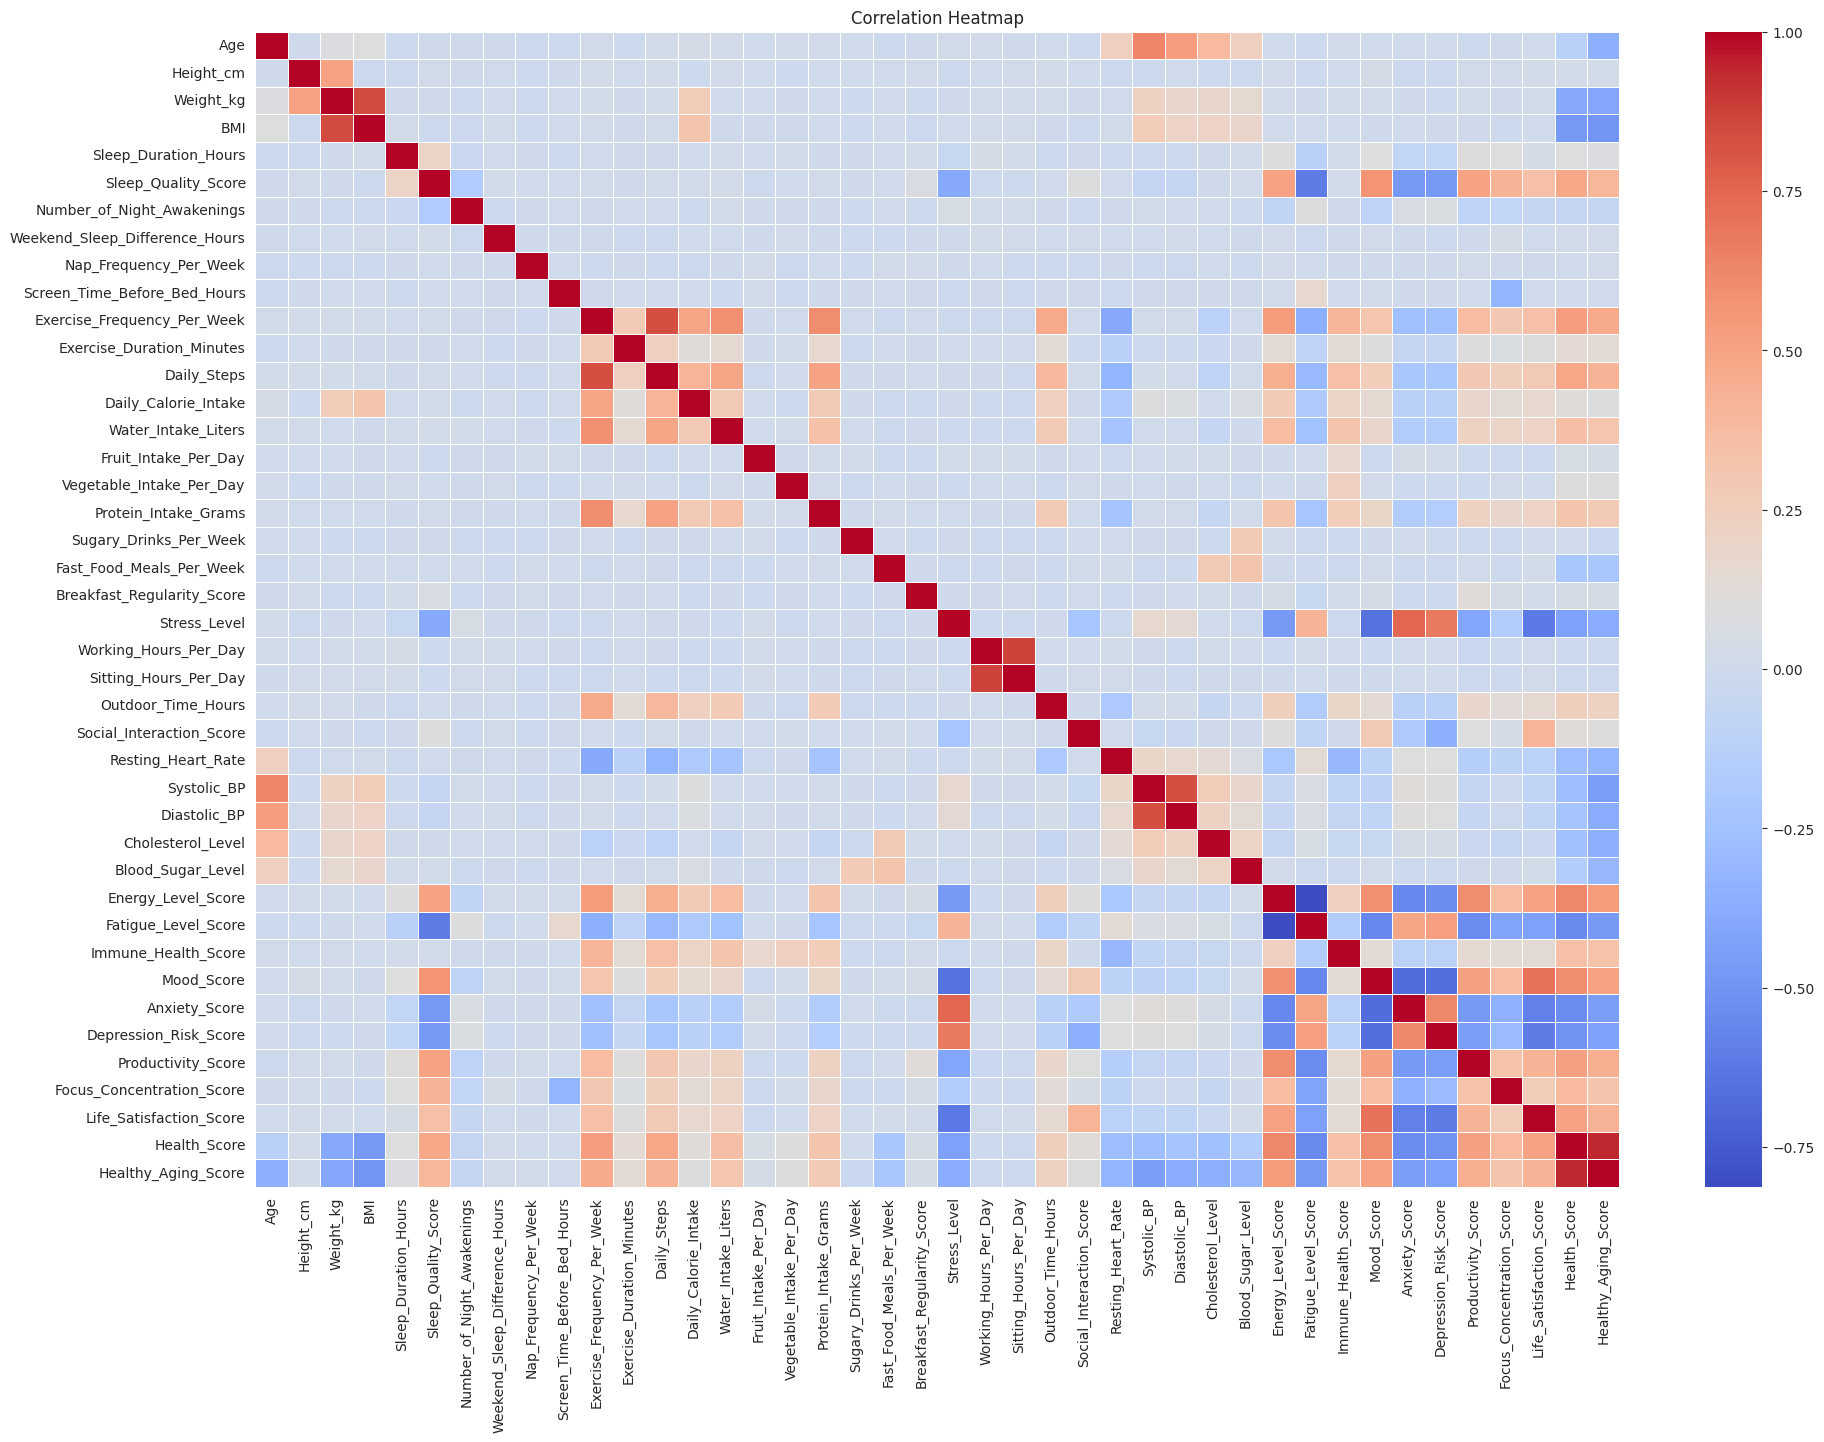

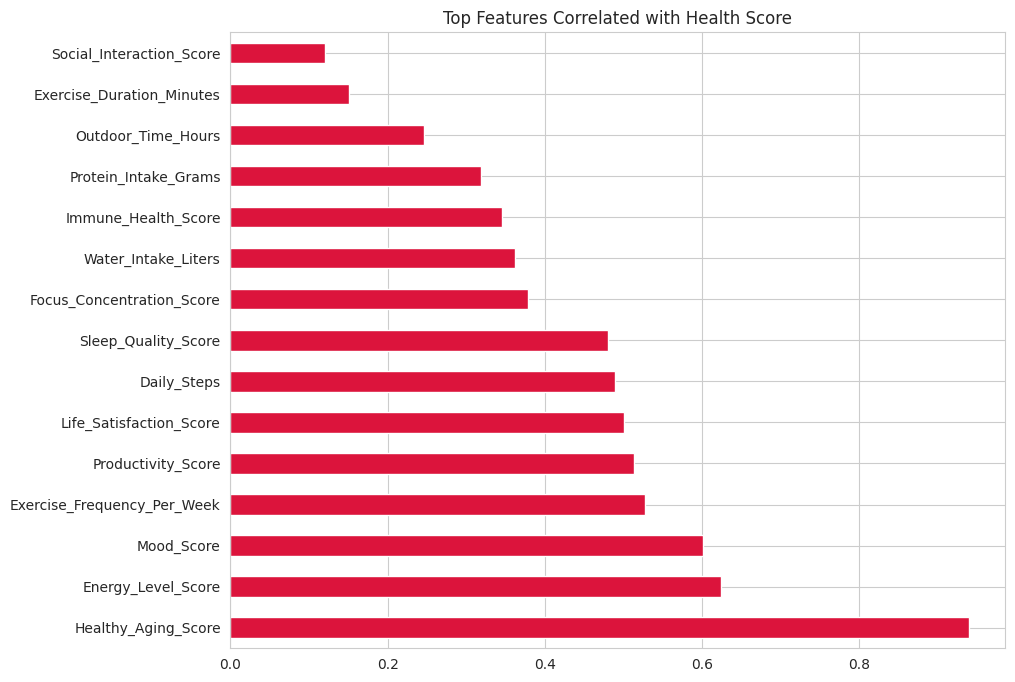

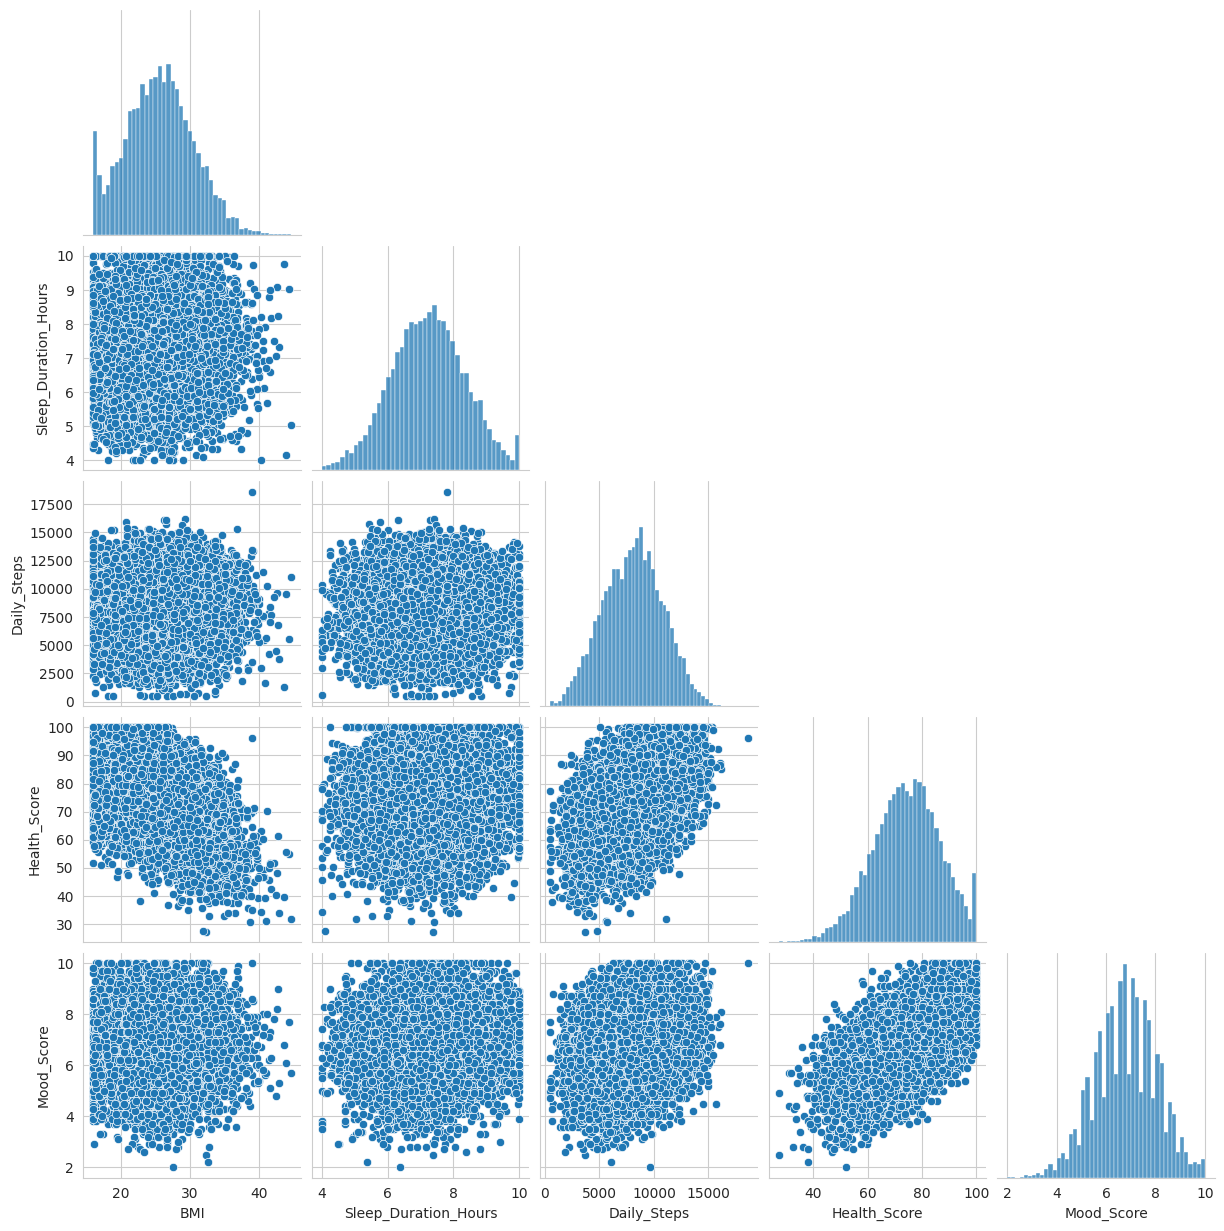

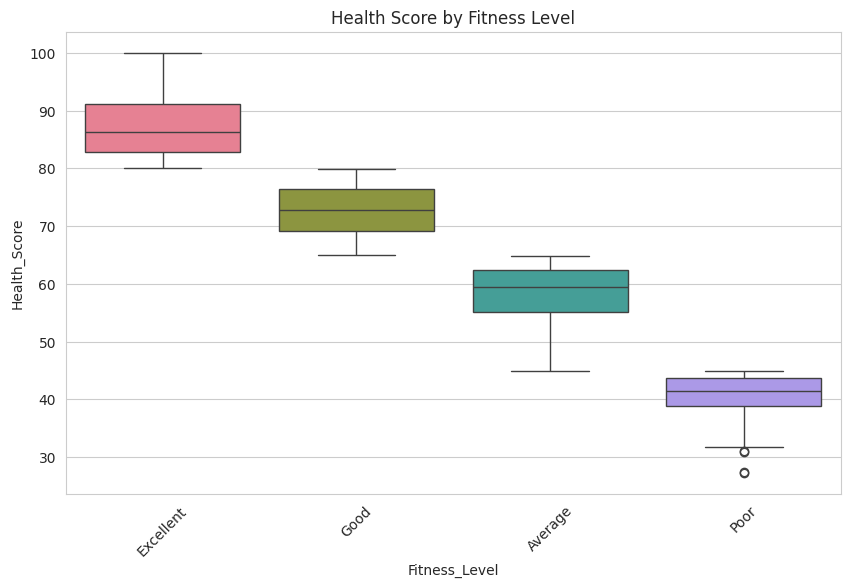

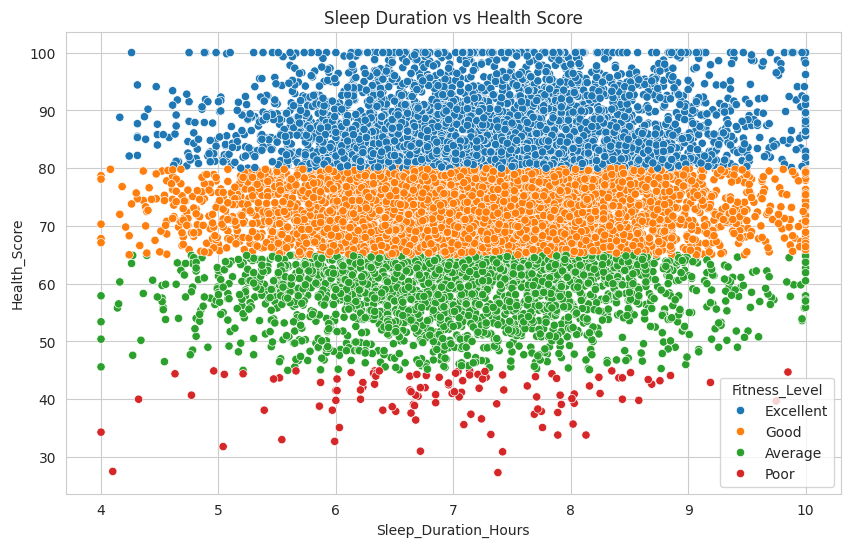

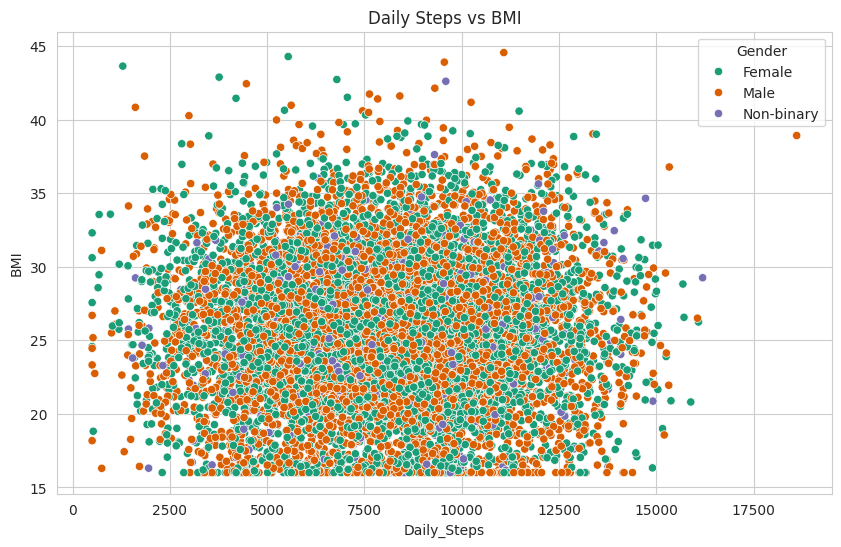

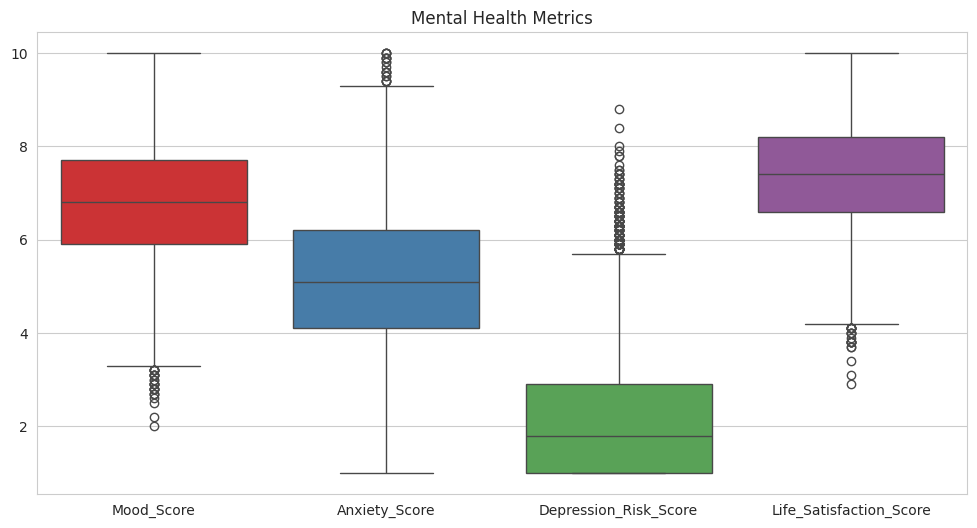

Visualization Dashboard Completed Successfully!


In [15]:
# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ==========================================
# 1. DATA OVERVIEW
# ==========================================
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# 2. AGE DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, color='royalblue', kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# ==========================================
# 3. GENDER DISTRIBUTION
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.show()

# ==========================================
# 4. BMI DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(df['BMI'], bins=25, color='darkorange', kde=True)
plt.title('BMI Distribution')
plt.show()

# ==========================================
# 5. COUNTRY WISE RECORDS
# ==========================================
plt.figure(figsize=(12,6))
df['Country'].value_counts().head(10).plot(
    kind='bar',
    color='mediumseagreen'
)
plt.title('Top 10 Countries')
plt.ylabel('Count')
plt.show()

# ==========================================
# 6. SLEEP DURATION DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(
    df['Sleep_Duration_Hours'],
    bins=20,
    color='purple',
    kde=True
)
plt.title('Sleep Duration Distribution')
plt.show()

# ==========================================
# 7. SLEEP QUALITY SCORE
# ==========================================
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Gender',
    y='Sleep_Quality_Score',
    data=df,
    palette='coolwarm'
)
plt.title('Sleep Quality by Gender')
plt.show()

# ==========================================
# 8. EXERCISE FREQUENCY
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(
    df['Exercise_Frequency_Per_Week'],
    bins=10,
    color='teal'
)
plt.title('Exercise Frequency Per Week')
plt.show()

# ==========================================
# 9. DAILY STEPS DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(
    df['Daily_Steps'],
    bins=30,
    color='gold'
)
plt.title('Daily Steps Distribution')
plt.show()

# ==========================================
# 10. WATER INTAKE
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(
    df['Water_Intake_Liters'],
    bins=20,
    color='dodgerblue'
)
plt.title('Water Intake Distribution')
plt.show()

# ==========================================
# 11. STRESS LEVEL DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
sns.countplot(
    x='Stress_Level',
    data=df,
    palette='rocket'
)
plt.title('Stress Level Distribution')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 12. MOOD SCORE VS STRESS LEVEL
# ==========================================
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Stress_Level',
    y='Mood_Score',
    data=df,
    palette='Spectral'
)
plt.title('Mood Score vs Stress Level')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 13. HEALTH SCORE DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(
    df['Health_Score'],
    bins=20,
    color='limegreen',
    kde=True
)
plt.title('Health Score Distribution')
plt.show()

# ==========================================
# 14. FITNESS LEVEL DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
sns.countplot(
    x='Fitness_Level',
    data=df,
    palette='viridis'
)
plt.title('Fitness Level Distribution')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 15. WELLNESS CATEGORY
# ==========================================
plt.figure(figsize=(10,6))
sns.countplot(
    x='Wellness_Category',
    data=df,
    palette='Set3'
)
plt.title('Wellness Category Distribution')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 16. OBESITY RISK
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Obesity_Risk',
    data=df,
    palette='Reds'
)
plt.title('Obesity Risk')
plt.show()

# ==========================================
# 17. DIABETES RISK
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Diabetes_Risk',
    data=df,
    palette='Blues'
)
plt.title('Diabetes Risk')
plt.show()

# ==========================================
# 18. HYPERTENSION RISK
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Hypertension_Risk',
    data=df,
    palette='Greens'
)
plt.title('Hypertension Risk')
plt.show()

# ==========================================
# 19. CARDIOVASCULAR RISK
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Cardiovascular_Risk',
    data=df,
    palette='Purples'
)
plt.title('Cardiovascular Risk')
plt.show()

# ==========================================
# 20. EARLY WAKER ANALYSIS
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Early_Waker',
    data=df,
    palette='Accent'
)
plt.title('Early Waker Distribution')
plt.show()

# ==========================================
# 21. CORRELATION HEATMAP
# ==========================================
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(22,15))
sns.heatmap(
    numeric_cols.corr(),
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.show()

# ==========================================
# 22. TOP CORRELATED FEATURES WITH HEALTH SCORE
# ==========================================
corr = numeric_cols.corr()['Health_Score']
corr = corr.sort_values(ascending=False)

plt.figure(figsize=(10,8))
corr[1:16].plot(
    kind='barh',
    color='crimson'
)
plt.title('Top Features Correlated with Health Score')
plt.show()

# ==========================================
# 23. PAIRPLOT
# ==========================================
important_cols = [
    'BMI',
    'Sleep_Duration_Hours',
    'Daily_Steps',
    'Health_Score',
    'Mood_Score'
]

sns.pairplot(
    df[important_cols],
    corner=True,
    diag_kind='hist'
)
plt.show()

# ==========================================
# 24. HEALTH SCORE BY FITNESS LEVEL
# ==========================================
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Fitness_Level',
    y='Health_Score',
    data=df,
    palette='husl'
)
plt.title('Health Score by Fitness Level')
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 25. SLEEP VS HEALTH SCORE
# ==========================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Sleep_Duration_Hours',
    y='Health_Score',
    hue='Fitness_Level',
    data=df,
    palette='tab10'
)
plt.title('Sleep Duration vs Health Score')
plt.show()

# ==========================================
# 26. STEPS VS BMI
# ==========================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Daily_Steps',
    y='BMI',
    hue='Gender',
    data=df,
    palette='Dark2'
)
plt.title('Daily Steps vs BMI')
plt.show()

# ==========================================
# 27. MENTAL HEALTH DASHBOARD
# ==========================================
mental_cols = [
    'Mood_Score',
    'Anxiety_Score',
    'Depression_Risk_Score',
    'Life_Satisfaction_Score'
]

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df[mental_cols],
    palette='Set1'
)
plt.title('Mental Health Metrics')
plt.show()

print("Visualization Dashboard Completed Successfully!")

## feature engineering

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
    label_binarize
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [17]:
target = "Wellness_Category"

X = df.drop(columns=[target, "Person_ID"])
y = df[target]

In [18]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes:")
print(le.classes_)

Classes:
['Average' 'Excellent' 'Good' 'Poor']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (8000, 62)
Test Shape: (2000, 62)


In [20]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", len(categorical_cols))
print("Numeric:", len(numeric_cols))

Categorical: 20
Numeric: 42


In [21]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [22]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

In [23]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

    print("="*60)
    print(name)
    print("="*60)

    print("\nAccuracy:")
    print(acc)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    ))

Logistic Regression

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00       427
   Excellent       1.00      1.00      1.00       664
        Good       1.00      1.00      1.00       886
        Poor       1.00      1.00      1.00        23

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Decision Tree

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00       427
   Excellent       1.00      1.00      1.00       664
        Good       1.00      1.00      1.00       886
        Poor       1.00      1.00      1.00        23

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Random Forest

Acc

                 Model  Accuracy
0  Logistic Regression    1.0000
1        Decision Tree    1.0000
3    Gradient Boosting    1.0000
5                  SVM    0.9995
2        Random Forest    0.9970
4                  KNN    0.8965


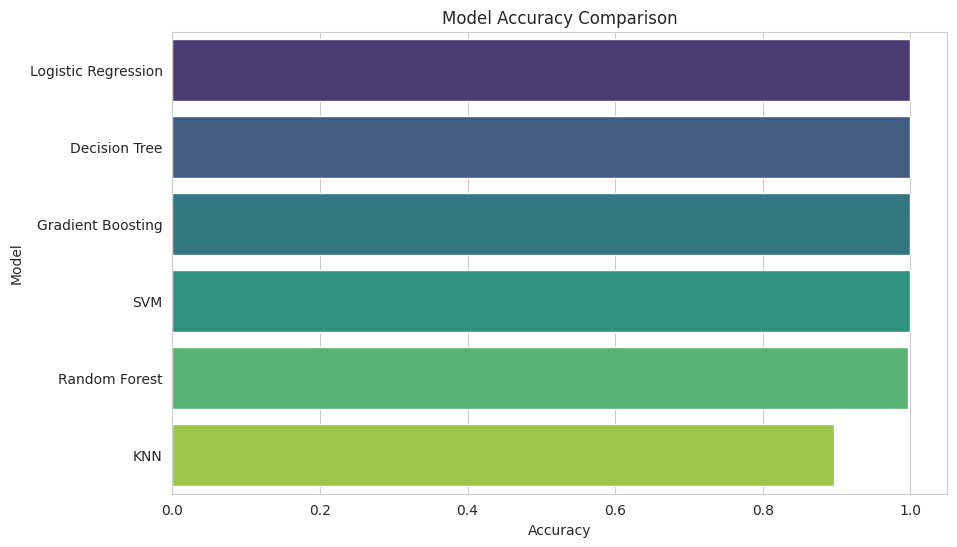

In [24]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.show()

In [25]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [26]:
best_model = models[best_model_name]

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

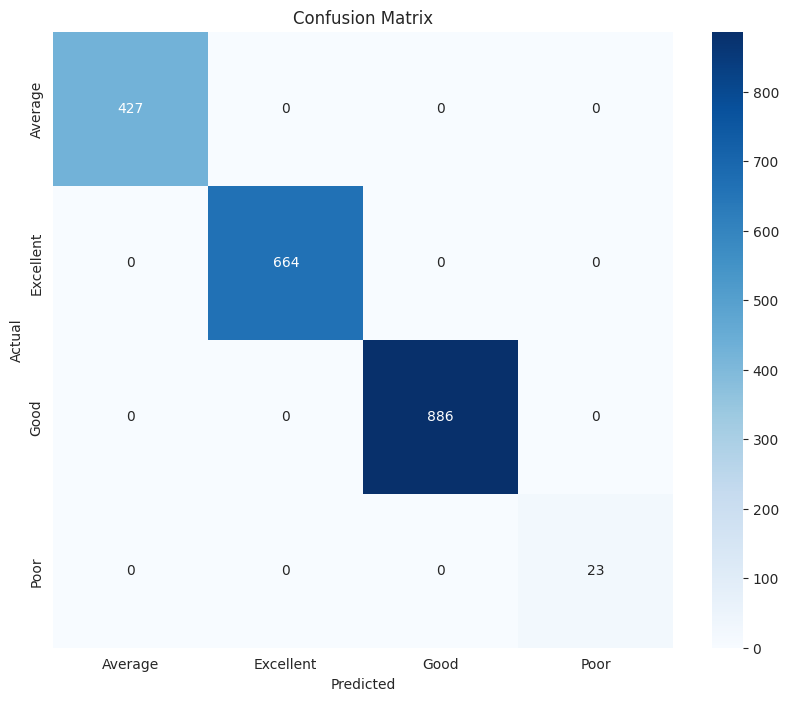

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

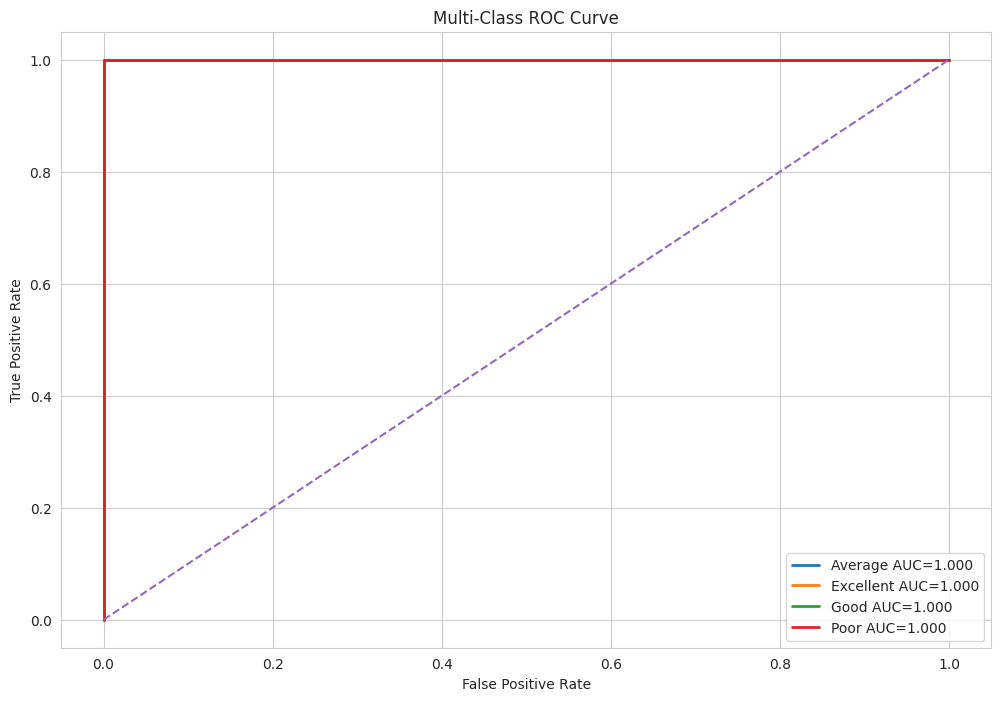

In [28]:
n_classes = len(np.unique(y_encoded))

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)

y_score = best_pipeline.predict_proba(X_test)

plt.figure(figsize=(12,8))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{le.classes_[i]} AUC={roc_auc:.3f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

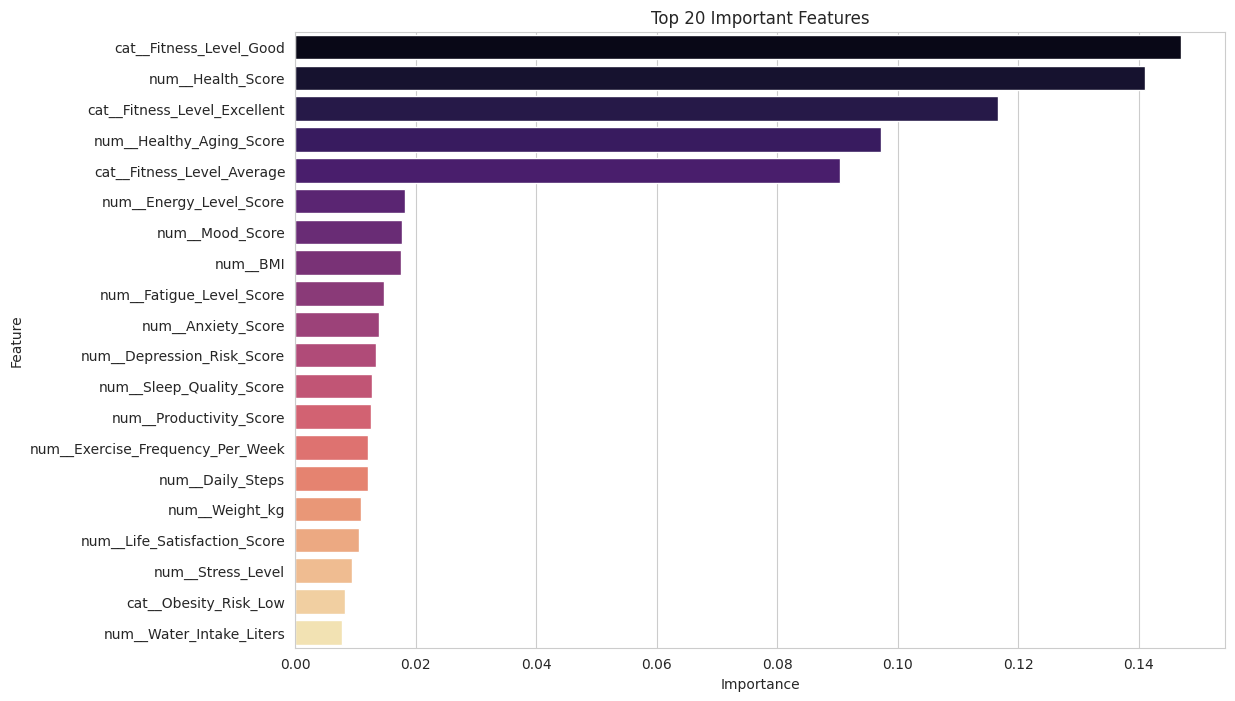

In [29]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importance = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_imp = feature_imp.sort_values(
    by="Importance",
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_imp,
    x="Importance",
    y="Feature",
    palette="magma"
)

plt.title("Top 20 Important Features")
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!!!!!